In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

SEED = 42
np.random.seed(SEED)

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


In [8]:
import os
df = pd.read_csv("global_hantavirus_surveillance_dataset_2026.csv")
print(f'\n Loaded:Successfully')


 Loaded:Successfully


In [9]:
# Basic inspection 
print('-' *60)
print(f'Shape: {df.shape[0]:,}, rows, {df.shape[1]} columns')
print('-' *60)
print('\n Columns detected:')
for i, col in enumerate(df.columns, 1):
    print(f' {i:>2}. {col}')

------------------------------------------------------------
Shape: 2,000, rows, 19 columns
------------------------------------------------------------

 Columns detected:
  1. case_id
  2. country
  3. region
  4. report_date
  5. virus_strain
  6. transmission_type
  7. exposure_source
  8. patient_age
  9. gender
 10. symptoms
 11. hospitalization
 12. fatality
 13. recovery_days
 14. temperature_celsius
 15. humidity_percent
 16. rodent_presence_index
 17. quarantine_days
 18. population_density
 19. air_quality_index


In [10]:
display(df.head())

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   object 
 9   symptoms               2000 non-null   object 
 10  hospitalization        2000 non-null   object 
 11  fatality               2000 non-null   object 
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rode

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,2000,2000,HV2026_02000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2000,10,Bolivia,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,2000,1850,West Jennifer,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
report_date,2000,490,18-01-2026,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
virus_strain,2000,5,Sin Nombre,431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,2000,2,Human-to-Human,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exposure_source,2000,6,Cruise Exposure,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_age,2000.0,NaN,NaN,NaN,45.196,19.115001,12.0,29.0,46.0,62.0,78.0
gender,2000,2,Male,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
symptoms,2000,5,"Fever, Muscle Pain, Fatigue",405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Missing Value Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found')
else:
    print('Missing values detected:')
    display(missing_df)
    # Fill numeric columns with median, categorical with mode
    for col in missing_df.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f' {col}:filled with median')
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'  {col}: filled with mode')     
    

Missing values detected:


,Missing Count,Missing %
recovery_days,155,7.75


 recovery_days:filled with median


In [14]:
# 4.2 Duplicate Checking
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f' Removed {dupes} duplicates.New shape: {df.shape}')

Duplicate rows: 0


In [15]:
# 4.3 Data Type Corrections
# Convert date column if present
date_cols = [c for c in df.columns if 'date' in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f' {col} converted to datetime')

# Normalize binary/boolean columns
for col in ['hospitalization', 'fatality']:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.lower().map(
                {'yes': 1, 'no': 0, 'true': 1, 'false': 0, '1': 1, '0': 0}
            ).fillna(df[col])
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    print(f' {col} normalized to 0/1 integers')

print('\n Data types after correction:')
print(df.dtypes)

 report_date converted to datetime
 hospitalization normalized to 0/1 integers
 fatality normalized to 0/1 integers

 Data types after correction:
case_id                          object
country                          object
region                           object
report_date              datetime64[ns]
virus_strain                     object
transmission_type                object
exposure_source                  object
patient_age                       int64
gender                           object
symptoms                         object
hospitalization                   int64
fatality                          int64
recovery_days                   float64
temperature_celsius             float64
humidity_percent                float64
rodent_presence_index             int64
quarantine_days                   int64
population_density                int64
air_quality_index                 int64
dtype: object


In [16]:
# 4.4 Categorical Inspection
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns and unique values:')
for col in cat_cols:
    print(f' {col}: {df[col].nunique()} unique  {df[col].unique()[:8]}')

Categorical columns and unique values:
 case_id: 2000 unique  ['HV2026_00001' 'HV2026_00002' 'HV2026_00003' 'HV2026_00004'
 'HV2026_00005' 'HV2026_00006' 'HV2026_00007' 'HV2026_00008']
 country: 10 unique  ['Canada' 'Bolivia' 'Chile' 'Argentina' 'Peru' 'Uruguay' 'USA' 'Brazil']
 region: 1850 unique  ['Lake Rickyside' 'East Crystal' 'Rossmouth' 'West Ryan' 'Mariaberg'
 'Port Cheryl' 'Bowenberg' 'Payneport']
 virus_strain: 5 unique  ['Sin Nombre' 'Seoul' 'Dobrava' 'Puumala' 'Andes']
 transmission_type: 2 unique  ['Rodent-to-Human' 'Human-to-Human']
 exposure_source: 6 unique  ['Agricultural Exposure' 'Home Infestation' 'Rodent Exposure'
 'Forest Exposure' 'Cruise Exposure' 'Warehouse Exposure']
 gender: 2 unique  ['Male' 'Female']
 symptoms: 5 unique  ['Headache, Vomiting, Fever' 'Fever, Muscle Pain, Fatigue'
 'Fever, Cough, Headache' 'Fatigue, Nausea, Chills'
 'Shortness of Breath, Fever']


In [17]:
# Outlier Inspection (IQR Method)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude binary columns from outlier check
binary_cols = [c for c in num_cols if df[c].nunique() <= 2]
check_cols = [c for c in num_cols if c not in binary_cols]

print('Outlier summary (IQR method):')

outlier_summary = []

for col in check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count values below lower bound or above upper bound
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Lower': lower,
        'Upper': upper,
        'Outliers': n_out
    })

display(pd.DataFrame(outlier_summary))

print('\nOutliers noted - capped values only if needed per column below.')

Outlier summary (IQR method):


,Column,Lower,Upper,Outliers
0,patient_age,-20.5000,111.5000,0
1,recovery_days,-10.0000,62.0000,0
2,temperature_celsius,8.5000,39.7000,17
3,humidity_percent,4.0125,125.3125,0
4,rodent_presence_index,-4.5000,15.5000,0
5,quarantine_days,-11.5000,32.5000,0
6,population_density,-5620.0000,15610.0000,0
7,air_quality_index,-124.3750,444.6250,0



Outliers noted - capped values only if needed per column below.


In [18]:
# Safe copy of clean data
df_clean = df.copy()
print(f' \n ✅ Cleaning complete. Final shape: {df_clean.shape}')

 
 ✅ Cleaning complete. Final shape: (2000, 19)


In [19]:
# Key Dataset Insights Through Visualization
# Helper: safe column check
def col_exists(col):
    return col in df_clean.columns

PALETTE = sns.color_palette('Set2', 12)

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

def generate_hantavirus_dashboard(df_clean, PALETTE):
    """
    Merges six distinct epidemiological code snippets into a single,
    cohesive, production-ready visualization dashboard.
    """
    # Defensive programming: localized column availability check
    def col_exists(col_name):
        return col_name in df_clean.columns
    # Create a single master canvas (20 inches wide, 28 inches tall)
    fig = plt.figure(figsize=(20, 28))
    # Establish a global 5-row by 2-column grid layout matrix
    gs = GridSpec(5,2, figure=fig, hspace=0.4, wspace=0.28)

    # Plot 1: Cases by Country (Spans across both columns in Row 0)
    if col_exists('Country'):
        ax0 = fig.add_subplot(gs[0, :])
        top_countries = df_clean['country'].value_counts().head(15)
        top_countries.plot(kind='bar', color=PALETTE, edgecolor='white', ax=ax0)
        ax0.set_title('Top 15 Countries by Reported Hantavirus Cases', fontweight='bold', pad=12, fontsize=14)
        ax0_set_xlabel('Country', fontsize=11)
        ax0_set_ylabel('Number of Cases', fontsize=11)
        ax0.tick_params(axis='x', rotation=40)
        ax0_yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))


    # Plot 2: Virus Strain Distribution (Row 1, Column 0)
    if col_exists('virus_strain'):
        ax1 = fig.add_subplots(gs[1, 0])
        strain_counts = df_clean['virus_strain'].value_counts()
        ax1.pie(
            strain_counts,
            labels=strain_counts.index,
            auropct='%1.1f%%',
            colors=PALETTE[:len(strain_counts)],
            startangle=140, pctdistance=0.82
        )
        ax1.set_title('Distribution of Hantavirus Strains', fontweight='bold', pad=12, fontsize=14)

    # Plot 4: Exposure Source Analysis (Row 1, Column 1)
    if col_exists('exposure_source'):
        ax2 = fig.add_subplot(gs[1, 1])
        exp_counts = df_clean['exposure_source'].value_counts()
        bars = ax2.barh(exp_counts.index, exp_counts.values,  color=PALETTE[:len(exp_counts)], edgecolor='white')
        ax2.set_title('Cases by Exposure Source', fontweight='bold', pad=12, fontsize=14)
        ax0.set_xlabel('Number of Cases', fontsize=11)
        ax0.set_ylabel('Exposure Source', fontsize=11)
        for bars in bars:
            ax2.text(bar.get_width() + 5,  bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}', va='center', fontsize=9)

    # Plot 3: Transmission Type Comparison (Row 2, Columns 0 & 1)
    if col_exists('transmission_type'):
        ax3 = fig.add_subplot(gs[2, 0])
        tx_counts = df_clean['transmission_type'].value_counts()
        tx_counts.plot(kind='bar', ax=ax3, color=PALETTE, edgecolor='white')
        ax3.set_title('Cases by Transmission Type', fontweight='bold', fontsize=14)
        ax3.set_xlabel('Transmission Type', fontsize=11)
        ax3.set_ylabel('Count', fontsize=11)
        ax3.tick_params(axis='x', rotation=30)


        if col_exists('fatality'):
            ax4 = fig.add_subplots(gs[2, 1])
            fat_rate = df_clean.groupby('transmission_type')['fatality'].mean().sort_values(ascending=False)
            fat_rate.plot(kind='bar', ax=ax4, color=sns.color_palette('Reds_r', len(fat_rate)), edgecolor='white')
            ax4.set_title('Fatality Rate by Transmission Type', fontweight='bold', fontsize=14)
            ax4.set_xlabel('Transmission Type', fontsize=11)
            ax4.set_ylabel('Fatality Rate', fontsize=11)
            ax4.tick_params(axis='x', rotation=30)
            ax4.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # Plot 5: Age Distribution & Vulnerability (Row 3, Columns 0 & 1)
    if col_exists('patient_age'):
        ax5 = fig.add_subplot(gs[3, 0])
        ax5.hist((df_clean['patient_age'].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
        ax5.set_title('Age Distribution of Patients', fontweight='bold', fontsize=14)
        ax5.set_xlabel('Age (years)', fontsize=11)
        ax5.set_ylabel('Count', fontsize=11)

        if col_exists('fatality'):
            ax6 = fig.add_subplots(gs[3, 1])
            # Explicit copy to protect parent DataFrame structure and avoid warnings
            df_age_analysis = df_clean.copy()
            df_age_analysis['fatality_label'] = df_age_analysis['fatality'].map({0: 'Survived', 1: 'Fatal'})
            sns.boxplot(data= df_age_analysis, x='fatality_label', y='patient_age', palette={'Survived': '#4CAF50', 'Fatal': '#E53935'}, ax=ax6)
            ax6.set_title('Age vs Fatality Outcome', fontweight='bold', fontsize=14)
            ax6.set_xlabel('Outcome', fontsize=11)
            ax6.set_ylabel('Age (years)', fontsize=11)
    # Plot 6: Gender Distribution (Row 4, Columns 0 & 1)
    if col_exists('gender'):
        ax7 = fig.add_subplot(gs[4, 0])
        g_counts = df_clean['gender'].value_counts()
        g_counts.plot(kind='bar', ax=ax7, color=['#42A5F5', '#EF5350', '#66BB6A'][:len(g_counts)], edgecolor='white')
        ax7.set_title('Cases by Gender', fontweight='bold', fontsize=14)
        ax7.set_xlabel('Gender', fontsize=11)
        ax7.set_ylabel('Count', fontsize=11)
        ax7.tick_params(axis='x', rotation=0)


        if col_exists('fatality'):
            ax8 = fig.add_subplot(gs[4, 1])
            fat_by_gender = df_clean.groupby('gender')['fatality'].mean().sort_values(ascending=False)
            fat_by_gender.plot(kind='bar', ax=ax8, color=['#42A5F5', '#EF5350', '#66BB6A'][:len(fat_by_gender)], edgecolor='white')
            ax8.set_title('Fatality Rate by Gender', fontweight='bold', fontsize=14)
            ax8.set_xlabel('Gender', fontsize=11)
            ax8.set_ylabel('Fatality Rate', fontsize=11)
            ax8.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
            ax8.tick_params(axis='x', rotation=0)

    # Single layout rendering command
    plt.show()

    # Consolidated Strategic Analysis Report
    print("\n" + "="*80)
    print("📋 SYSTEM CONSOLIDATED REPORT: HANTAVIRUS EPIDEMIOLOGICAL INSIGHTS")
    print("="*80)
    print("🌐 GEOGRAPHIC DISTRIBUTION : High case counts reflect local surveillance capacities,")
    print("                             rodent biodiversity, and exposure vectors. Prioritize")
    print("                             these vectors for proactive structural early-warning setups.")
    print("🧬 VIROLOGY STRAINS        : Diverse viral strains yield distinctly varied fatality matrix profiles.")
    print("                             Dominant strains map out future therapeutic R&D asset vectors.")
    print("🌬️ TRANSMISSION MODALITIES  : Highly elevated fatality pathways require direct community warnings.")
    print("                             Inhalation vectors inside confined spaces remain primary threats.")
    print("🌾 ENVIRONMENTAL EXPOSURE  : Dominant agricultural/domestic focal spaces highlight a clear need")
    print("                             for systemic structural rodent-proofing and local sanitation programs.")
    print("⏳ DEMOGRAPHIC VULNERABILITY: If advancing age groups exhibit amplified fatality dynamics, age is verified")
    print("                             as an active vulnerability metric. This requires localized screening.")
    print("🚻 SEX/GENDER METRICS      : Historic vectors demonstrate elevated exposure among male demographics,")
    print("                             driven by specific work profiles. This helps focus public outreach.")
    print("="*80 + "\n")                                                                                 

            
        
    
        
    
        
    
    

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1409290064.py, line 79)

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

def generate_hantavirus_dashboard(df_clean, PALETTE):
    """
    Merges six distinct epidemiological code snippets into a single,
    cohesive, production-ready visualization dashboard.
    """
    # Defensive programming: localized column availability check
    def col_exists(col_name):
        return col_name in df_clean.columns

    # Create a single master canvas (20 inches wide, 28 inches tall)
    fig = plt.figure(figsize=(20, 28))
    
    # Establish a global 5-row by 2-column grid layout matrix
    gs = GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.28)
    
    # Plot 1: Cases by Country (Spans across both columns in Row 0) 
    if col_exists('country'):
        ax0 = fig.add_subplot(gs[0, :])
        top_countries = df_clean['country'].value_counts().head(15)
        top_countries.plot(kind='bar', color=PALETTE, edgecolor='white', ax=ax0)
        ax0.set_title('Top 15 Countries by Reported Hantavirus Cases', fontweight='bold', pad=12, fontsize=14)
        ax0.set_xlabel('Country', fontsize=11)
        ax0.set_ylabel('Number of Cases', fontsize=11)
        ax0.tick_params(axis='x', rotation=40)
        ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Plot 2: Virus Strain Distribution (Row 1, Column 0)
    if col_exists('virus_strain'):
        ax1 = fig.add_subplot(gs[1, 0])
        strain_counts = df_clean['virus_strain'].value_counts()
        ax1.pie(
            strain_counts,
            labels=strain_counts.index,
            autopct='%1.1f%%',
            colors=PALETTE[:len(strain_counts)],
            startangle=140, pctdistance=0.82
        )
        ax1.set_title('Distribution of Hantavirus Strains', fontweight='bold', pad=12, fontsize=14)

    # Plot 4: Exposure Source Analysis (Row 1, Column 1)
    if col_exists('exposure_source'):
        ax2 = fig.add_subplot(gs[1, 1])
        exp_counts = df_clean['exposure_source'].value_counts()
        bars = ax2.barh(exp_counts.index, exp_counts.values,
                        color=PALETTE[:len(exp_counts)], edgecolor='white')
        ax2.set_title('Cases by Exposure Source', fontweight='bold', pad=12, fontsize=14)
        ax2.set_xlabel('Number of Cases', fontsize=11)
        ax2.set_ylabel('Exposure Source', fontsize=11)
        for bar in bars:
            ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                     f'{int(bar.get_width()):,}', va='center', fontsize=9)

    # Plot 3: Transmission Type Comparison (Row 2, Columns 0 & 1)
    if col_exists('transmission_type'):
        ax3 = fig.add_subplot(gs[2, 0])
        tx_counts = df_clean['transmission_type'].value_counts()
        tx_counts.plot(kind='bar', ax=ax3, color=PALETTE, edgecolor='white')
        ax3.set_title('Cases by Transmission Type', fontweight='bold', fontsize=14)
        ax3.set_xlabel('Transmission Type', fontsize=11)
        ax3.set_ylabel('Count', fontsize=11)
        ax3.tick_params(axis='x', rotation=30)

        if col_exists('fatality'):
            ax4 = fig.add_subplot(gs[2, 1])
            fat_rate = df_clean.groupby('transmission_type')['fatality'].mean().sort_values(ascending=False)
            fat_rate.plot(kind='bar', ax=ax4, color=sns.color_palette('Reds_r', len(fat_rate)), edgecolor='white')
            ax4.set_title('Fatality Rate by Transmission Type', fontweight='bold', fontsize=14)
            ax4.set_xlabel('Transmission Type', fontsize=11)
            ax4.set_ylabel('Fatality Rate', fontsize=11)
            ax4.tick_params(axis='x', rotation=30)
            ax4.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # Plot 5: Age Distribution & Vulnerability (Row 3, Columns 0 & 1)
    if col_exists('patient_age'):
        ax5 = fig.add_subplot(gs[3, 0])
        ax5.hist(df_clean['patient_age'].dropna(), bins=25,
                 color='steelblue', edgecolor='white', alpha=0.85)
        ax5.set_title('Age Distribution of Patients', fontweight='bold', fontsize=14)
        ax5.set_xlabel('Age (years)', fontsize=11)
        ax5.set_ylabel('Count', fontsize=11)

        if col_exists('fatality'):
            ax6 = fig.add_subplot(gs[3, 1])
            # Explicit copy to protect parent DataFrame structure and avoid warnings
            df_age_analysis = df_clean.copy()
            df_age_analysis['fatality_label'] = df_age_analysis['fatality'].map({0: 'Survived', 1: 'Fatal'})
            sns.boxplot(data=df_age_analysis, x='fatality_label', y='patient_age',
                        palette={'Survived': '#4CAF50', 'Fatal': '#E53935'}, ax=ax6)
            ax6.set_title('Age vs Fatality Outcome', fontweight='bold', fontsize=14)
            ax6.set_xlabel('Outcome', fontsize=11)
            ax6.set_ylabel('Age (years)', fontsize=11)

    # Plot 6: Gender Distribution (Row 4, Columns 0 & 1)
    if col_exists('gender'):
        ax7 = fig.add_subplot(gs[4, 0])
        g_counts = df_clean['gender'].value_counts()
        g_counts.plot(kind='bar', ax=ax7,
                      color=['#42A5F5', '#EF5350', '#66BB6A'][:len(g_counts)],
                      edgecolor='white')
        ax7.set_title('Cases by Gender', fontweight='bold', fontsize=14)
        ax7.set_xlabel('Gender', fontsize=11)
        ax7.set_ylabel('Count', fontsize=11)
        ax7.tick_params(axis='x', rotation=0)

        if col_exists('fatality'):
            ax8 = fig.add_subplot(gs[4, 1])
            fat_by_gender = df_clean.groupby('gender')['fatality'].mean().sort_values(ascending=False)
            fat_by_gender.plot(kind='bar', ax=ax8,
                               color=['#42A5F5', '#EF5350', '#66BB6A'][:len(fat_by_gender)],
                               edgecolor='white')
            ax8.set_title('Fatality Rate by Gender', fontweight='bold', fontsize=14)
            ax8.set_xlabel('Gender', fontsize=11)
            ax8.set_ylabel('Fatality Rate', fontsize=11)
            ax8.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
            ax8.tick_params(axis='x', rotation=0)

    # Single layout rendering command
    plt.show()

    # Consolidated Strategic Analysis Report
    print("\n" + "="*80)
    print("📋 SYSTEM CONSOLIDATED REPORT: HANTAVIRUS EPIDEMIOLOGICAL INSIGHTS")
    print("="*80)
    print("🌐 GEOGRAPHIC DISTRIBUTION : High case counts reflect local surveillance capacities,")
    print("                             rodent biodiversity, and exposure vectors. Prioritize")
    print("                             these vectors for proactive structural early-warning setups.")
    print("🧬 VIROLOGY STRAINS        : Diverse viral strains yield distinctly varied fatality matrix profiles.")
    print("                             Dominant strains map out future therapeutic R&D asset vectors.")
    print("🌬️ TRANSMISSION MODALITIES  : Highly elevated fatality pathways require direct community warnings.")
    print("                             Inhalation vectors inside confined spaces remain primary threats.")
    print("🌾 ENVIRONMENTAL EXPOSURE  : Dominant agricultural/domestic focal spaces highlight a clear need")
    print("                             for systemic structural rodent-proofing and local sanitation programs.")
    print("⏳ DEMOGRAPHIC VULNERABILITY: If advancing age groups exhibit amplified fatality dynamics, age is verified")
    print("                             as an active vulnerability metric. This requires localized screening.")
    print("🚻 SEX/GENDER METRICS      : Historic vectors demonstrate elevated exposure among male demographics,")
    print("                             driven by specific work profiles. This helps focus public outreach.")
    print("="*80 + "\n")

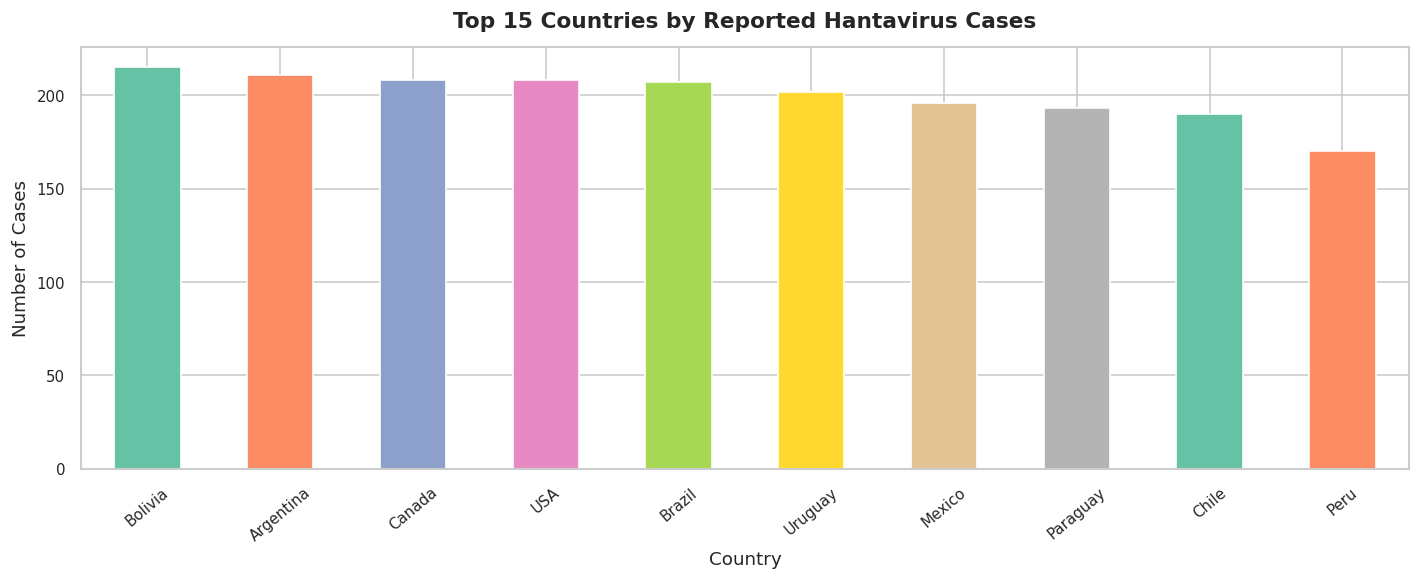

📌 Insight: Countries with the highest case counts reflect surveillance capacity, rodent biodiversity, and population exposure. These nations should be prioritized for targeted outbreak response and early-warning systems.


In [22]:
# Plot 1: Cases by Country
if col_exists('country'):
    top_countries = df_clean['country'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_countries.plot(kind='bar', color=PALETTE, edgecolor='white', ax=ax)
    ax.set_title('Top 15 Countries by Reported Hantavirus Cases', fontweight='bold', pad=12)
    ax.set_xlabel('Country')
    ax.set_ylabel('Number of Cases')
    ax.tick_params(axis='x', rotation=40)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()
    print('📌 Insight: Countries with the highest case counts reflect surveillance capacity,'
          ' rodent biodiversity, and population exposure. These nations should be prioritized'
          ' for targeted outbreak response and early-warning systems.')

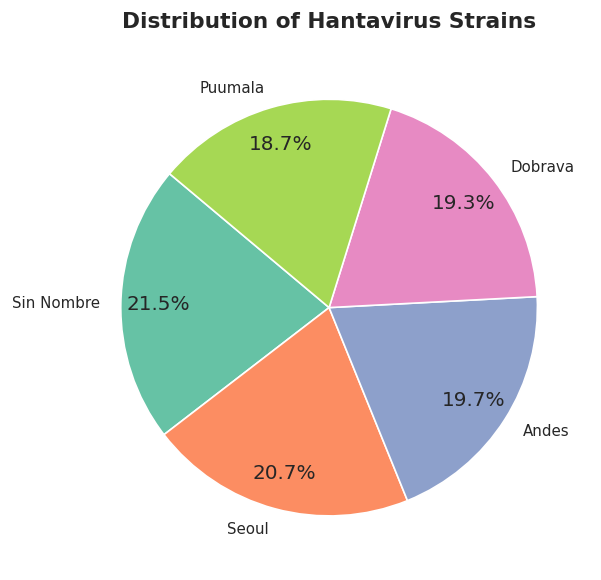

📌 Insight: Different strains carry different fatality profiles.  Dominant strains inform vaccine R&D priorities and region-specific treatment protocols.


In [23]:
# Plot 2: Virus Strain Distribution
if col_exists('virus_strain'):
    strain_counts = df_clean['virus_strain'].value_counts()
    fig, ax = plt.subplots(figsize=(9, 5))
    wedges, texts, autotexts = ax.pie(
        strain_counts,
        labels=strain_counts.index,
        autopct='%1.1f%%',
        colors=PALETTE[:len(strain_counts)],
        startangle=140, pctdistance=0.82
    )
    ax.set_title('Distribution of Hantavirus Strains', fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()
    print('📌 Insight: Different strains carry different fatality profiles.',
          ' Dominant strains inform vaccine R&D priorities and region-specific treatment protocols.')

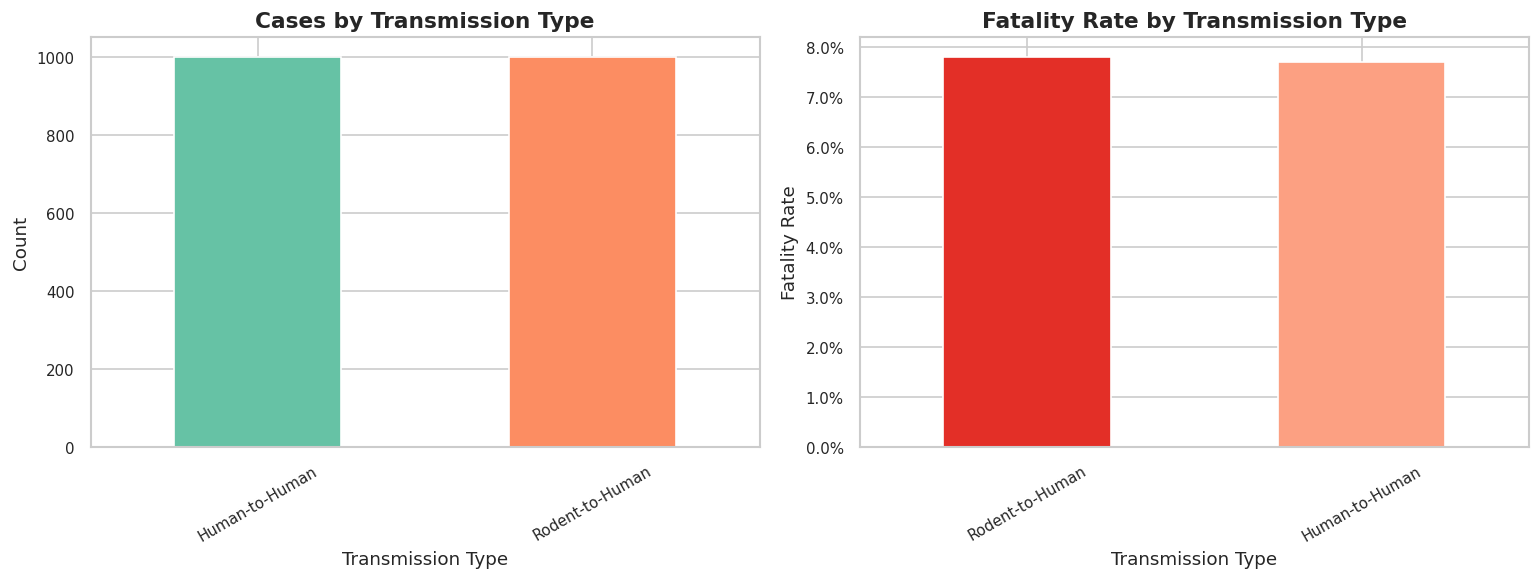

📌 Insight: Transmission pathways with higher fatality rates need immediate preventive messaging — inhalation exposure from enclosed spaces is often the deadliest route and is highly preventable with proper ventilation.


In [24]:
# Plot 3: Transmission Type Comparison
if col_exists('transmission_type'):
    fig, axes = plt.subplots(1,2, figsize=(13,5))

    # Count
    tx_counts = df_clean['transmission_type'].value_counts()
    tx_counts.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
    axes[0].set_title('Cases by Transmission Type', fontweight='bold')
    axes[0].set_xlabel('Transmission Type')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

    # Fatality rate by transmission type
    if col_exists('fatality'):
        fat_rate = df_clean.groupby('transmission_type')['fatality'].mean().sort_values(ascending=False)
        fat_rate.plot(kind='bar', ax=axes[1], color=sns.color_palette('Reds_r', len(fat_rate)), edgecolor='white')
        axes[1].set_title('Fatality Rate by Transmission Type', fontweight='bold')
        axes[1].set_xlabel('Transmission Type')
        axes[1].set_ylabel('Fatality Rate')
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()
print('📌 Insight: Transmission pathways with higher fatality rates need immediate'
          ' preventive messaging — inhalation exposure from enclosed spaces is often the'
          ' deadliest route and is highly preventable with proper ventilation.')

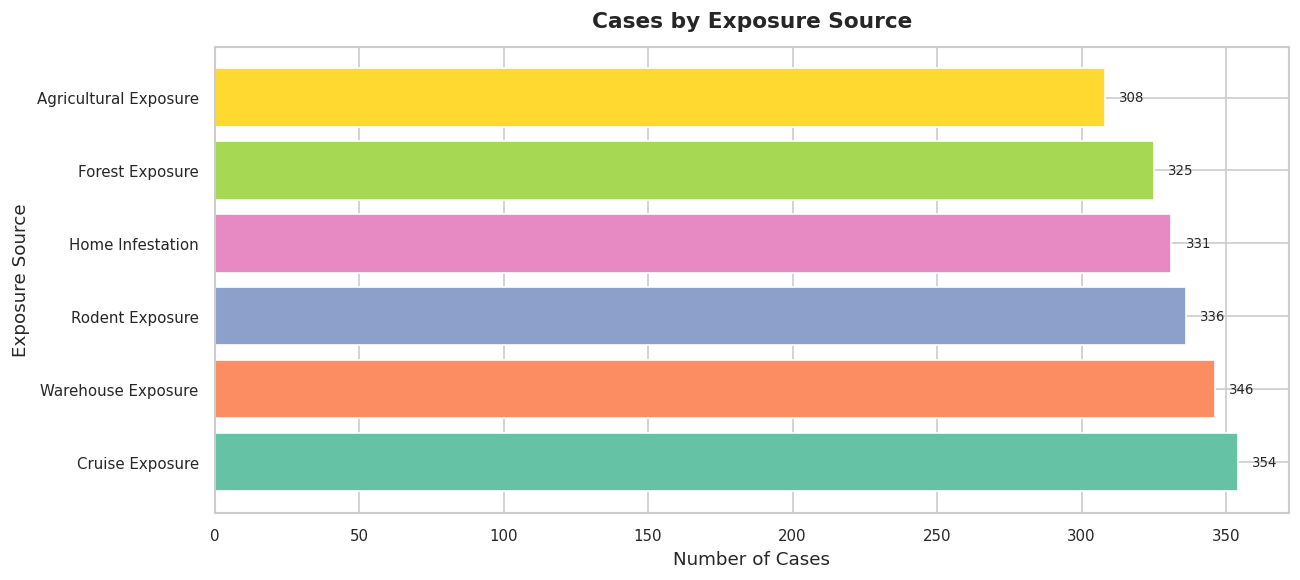

📌 Insight: Identifying dominant exposure sources enables precision interventions.  Agricultural and domestic settings showing high counts warrant rodent-proofing programs and community hygiene campaigns.


In [25]:
# Plot 4: Exposure Source Analysis
if col_exists('exposure_source'):
    exp_counts = df_clean['exposure_source'].value_counts()
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.barh(exp_counts.index, exp_counts.values, color=PALETTE[:len(exp_counts)], edgecolor='white')
    ax.set_title('Cases by Exposure Source', fontweight='bold', pad=12)
    ax.set_xlabel('Number of Cases')
    ax.set_ylabel('Exposure Source')
    for bar in bars:
        ax.text(bar.get_width() + 5,  bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
    print('📌 Insight: Identifying dominant exposure sources enables precision interventions.',
          ' Agricultural and domestic settings showing high counts warrant rodent-proofing'
          ' programs and community hygiene campaigns.')

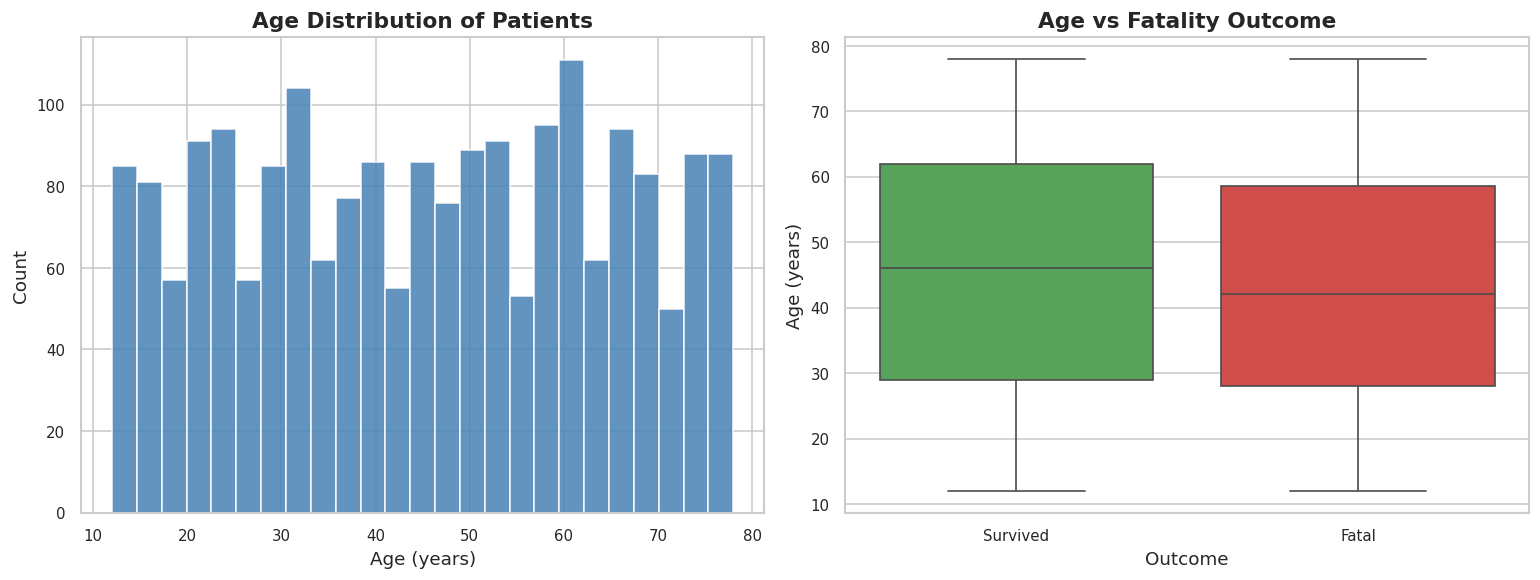

📌 Insight: If older age groups show higher fatality, this confirms age as a vulnerability factor. Targeted vaccination campaigns and early screening for the elderly population are critical.


In [26]:
# Plot 5: Age Distribution & Vulnerability 
if col_exists('patient_age'):
    fig, axes = plt.subplots(1,2, figsize=(13, 5))

    # Histogram
    axes[0].hist(df_clean['patient_age'].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title('Age Distribution of Patients', fontweight='bold')
    axes[0].set_xlabel('Age (years)')
    axes[0].set_ylabel('Count')

    # Age vs fatality (box plot)
    if col_exists('fatality'):
        df_clean['fatality_label'] = df_clean['fatality'].map({0: 'Survived', 1: 'Fatal'})
        sns.boxplot(data=df_clean,  x='fatality_label', y='patient_age', palette={'Survived': '#4CAF50', 'Fatal': '#E53935'}, ax=axes[1])
        axes[1].set_title('Age vs Fatality Outcome', fontweight='bold')
        axes[1].set_xlabel('Outcome')
        axes[1].set_ylabel('Age (years)')

    plt.tight_layout()
    plt.show()
    print('📌 Insight: If older age groups show higher fatality, this confirms age as a'
          ' vulnerability factor. Targeted vaccination campaigns and early screening for'
          ' the elderly population are critical.')   
    

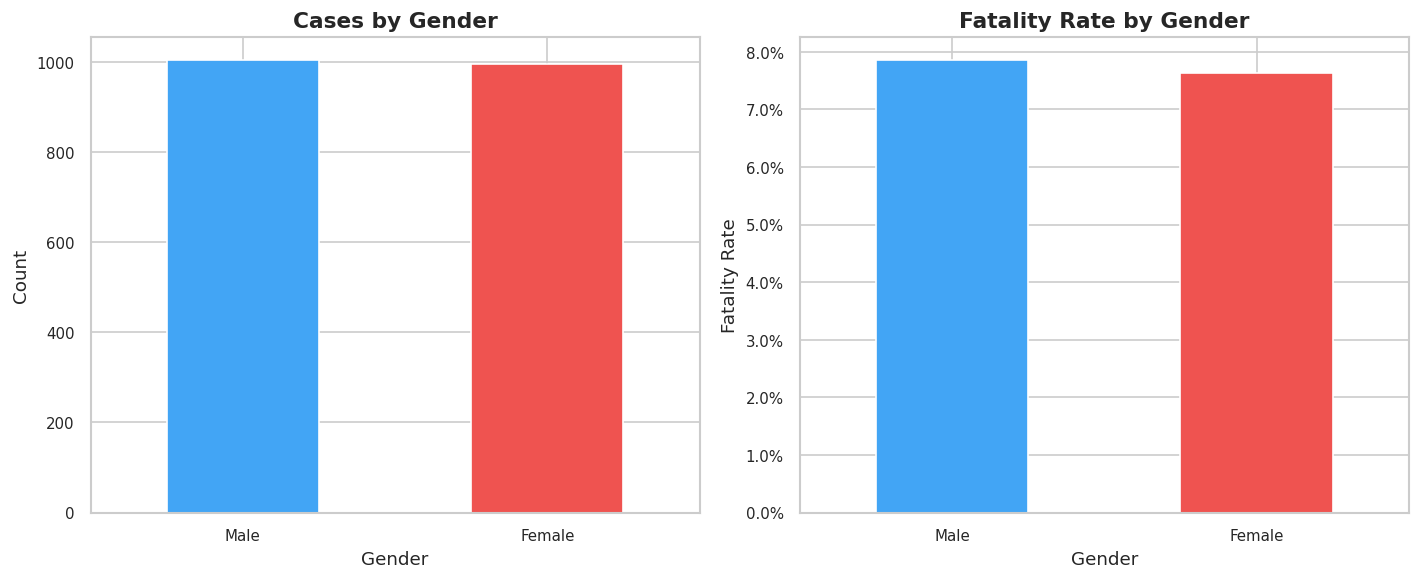

📌 Insight: Global literature shows males have higher Hantavirus exposure due to occupational and outdoor activities. Gender-disaggregated analysis guides targeted communication and prevention outreach.


In [27]:
# Plot 6: Gender Distribution
if col_exists('gender'):
    fig, axes = plt.subplots(1,2, figsize=(12, 5))

    # Case count by gender
    g_counts = df_clean['gender'].value_counts()
    g_counts.plot(kind='bar', ax=axes[0], color=['#42A5F5', '#EF5350', '#66BB6A'][:len(g_counts)], edgecolor='white')
    axes[0].set_title('Cases by Gender', fontweight='bold')
    axes[0].set_xlabel('Gender')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)

    # Fatality rate by gender
    if col_exists('fatality'):
        fat_by_gender = df_clean.groupby('gender')['fatality'].mean().sort_values(ascending=False)
        fat_by_gender.plot(kind='bar', ax=axes[1], color=['#42A5F5', '#EF5350', '#66BB6A'][:len(fat_by_gender)], edgecolor='white')
        axes[1].set_title('Fatality Rate by Gender', fontweight='bold')
        axes[1].set_xlabel('Gender')
        axes[1].set_ylabel('Fatality Rate')
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
    print('📌 Insight: Global literature shows males have higher Hantavirus exposure due'
          ' to occupational and outdoor activities. Gender-disaggregated analysis guides'
          ' targeted communication and prevention outreach.')
        

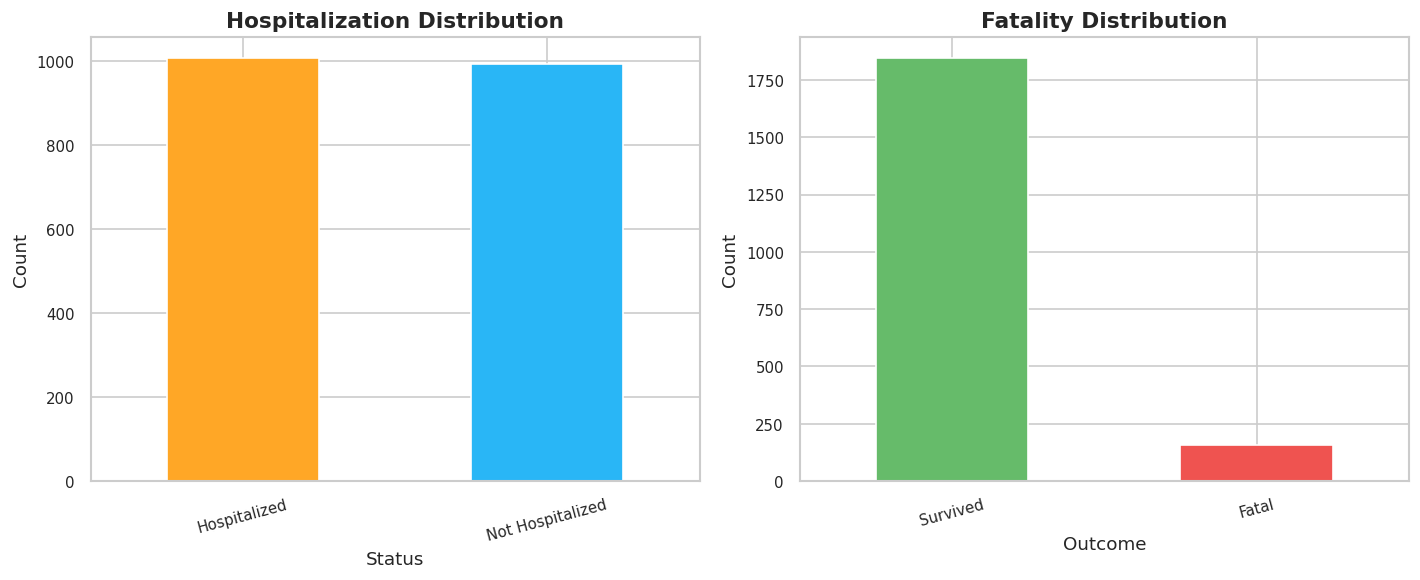

📌 Insight: Comparing hospitalization to fatality rates reveals care-seeking behavior  and healthcare access. High hospitalization with low fatality indicates effective  clinical management. The inverse signals healthcare system strain.


In [28]:
# Plot 7: Fatality vs Hospitalization
fig, axes = plt.subplots(1,2, figsize=(12, 5))

if col_exists('hospitalization'):
    h_counts = df_clean['hospitalization'].map({0: 'Not Hospitalized', 1: 'Hospitalized'}).value_counts()
    h_counts.plot(kind='bar', ax=axes[0], color=['#FFA726', '#29B6F6'], edgecolor='white')
    axes[0].set_title('Hospitalization Distribution', fontweight='bold')
    axes[0].set_xlabel('Status')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=15)

if col_exists('fatality'):
    f_counts = df_clean['fatality'].map({0: 'Survived', 1: 'Fatal'}).value_counts()
    f_counts.plot(kind='bar', ax=axes[1], color=['#66BB6A', '#EF5350'], edgecolor='white')
    axes[1].set_title('Fatality Distribution', fontweight='bold')
    axes[1].set_xlabel('Outcome')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print('📌 Insight: Comparing hospitalization to fatality rates reveals care-seeking behavior',
      ' and healthcare access. High hospitalization with low fatality indicates effective',
      ' clinical management. The inverse signals healthcare system strain.')

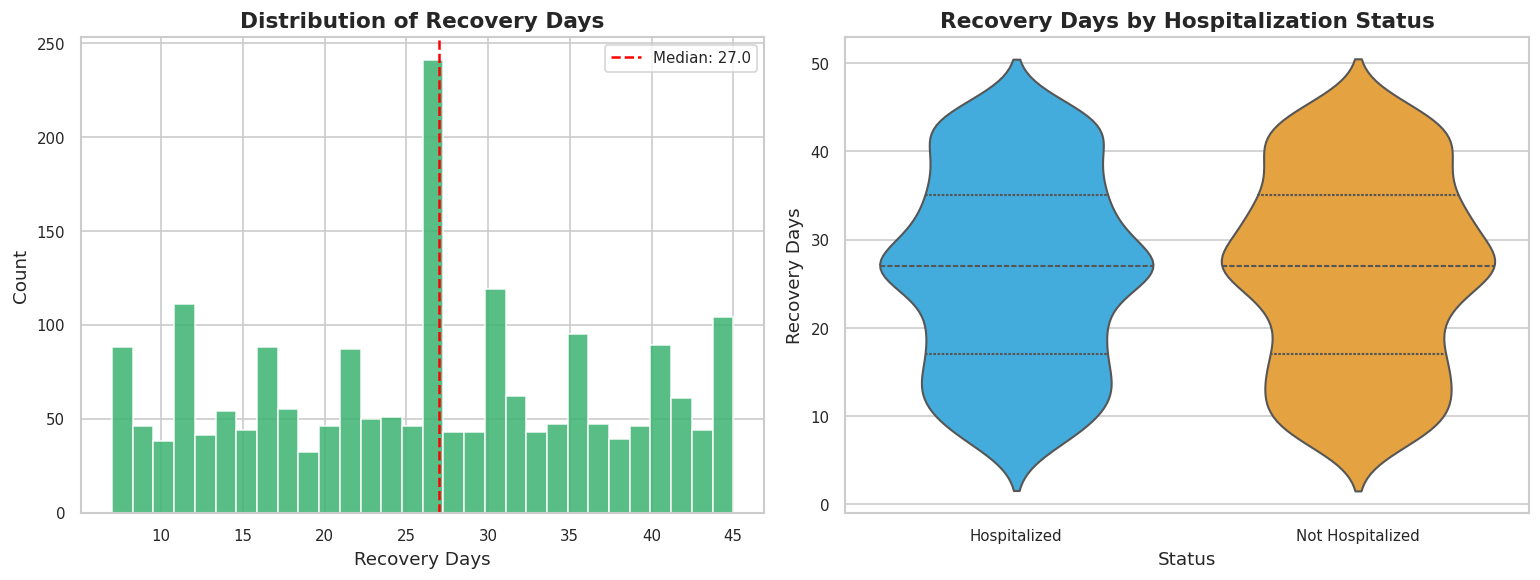

 Insight: Longer recovery times for hospitalized patients indicate disease severity.  Tracking recovery duration helps estimate healthcare resource allocation needs.


In [29]:
# Plot 8: Recovery Days Distribution
if col_exists('recovery_days'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histogram of recovery days
    axes[0].hist(df_clean['recovery_days'].dropna(), bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distribution of Recovery Days', fontweight='bold')
    axes[0].set_xlabel('Recovery Days')
    axes[0].set_ylabel('Count')
    axes[0].axvline(df_clean['recovery_days'].median(), color='red', linestyle='--', label=f"Median: {df_clean['recovery_days'].median():.1f}")
    axes[0].legend()
    
    # Recovery days by hospitalization
    if col_exists('hospitalization'):
        df_clean['hosp_label'] = df_clean['hospitalization'].map({0: 'Not Hospitalized', 1: 'Hospitalized'})
        sns.violinplot(data=df_clean, x='hosp_label', y='recovery_days', palette={'Not Hospitalized': '#FFA726', 'Hospitalized': '#29B6F6'}, ax=axes[1], inner='quartile')
        axes[1].set_title('Recovery Days by Hospitalization Status', fontweight='bold')
        axes[1].set_xlabel('Status')
        axes[1].set_ylabel('Recovery Days')

    plt.tight_layout()
    plt.show()
    print(' Insight: Longer recovery times for hospitalized patients indicate disease severity.',
          ' Tracking recovery duration helps estimate healthcare resource allocation needs.')


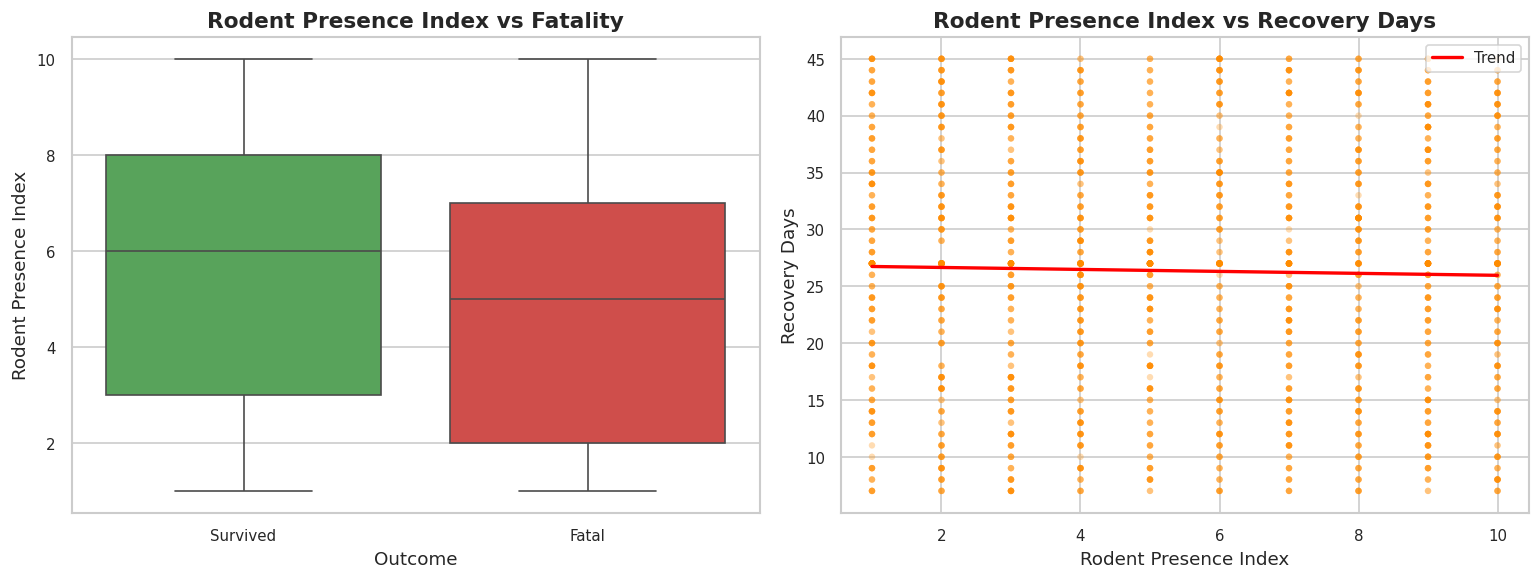

📌 Insight: A positive correlation between rodent presence and disease severity  validates rodent control as a primary prevention strategy. Areas with high rodent  indices should trigger immediate pest management and community advisories.


In [30]:
# Plot 9: Rodent Presence Index vs Outcomes
if col_exists('rodent_presence_index'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Rodent presence vs fatality (box)
    if col_exists('fatality'):
        sns.boxplot(data=df_clean, x='fatality_label', y='rodent_presence_index', palette={'Survived': '#4CAF50', 'Fatal': '#E53935'}, ax=axes[0])
        axes[0].set_title('Rodent Presence Index vs Fatality', fontweight='bold')
        axes[0].set_xlabel('Outcome')
        axes[0].set_ylabel('Rodent Presence Index')


    # Rodent presence vs recovery days (scatter)
    if col_exists('recovery_days'):
        axes[1].scatter(df_clean['rodent_presence_index'], df_clean['recovery_days'], alpha=0.3, color='darkorange', edgecolors='none', s=15)


        # Trend line
        mask = df_clean[['rodent_presence_index', 'recovery_days']].notna().all(axis=1)
        x = df_clean.loc[mask, 'rodent_presence_index']
        y = df_clean.loc[mask, 'recovery_days']
        m, b = np.polyfit(x, y, 1)
        axes[1].plot(np.sort(x), m * np.sort(x) + b, color='red', linewidth=2, label='Trend')
        axes[1].set_title('Rodent Presence Index vs Recovery Days', fontweight='bold')
        axes[1].set_xlabel('Rodent Presence Index')
        axes[1].set_ylabel('Recovery Days')
        axes[1].legend()

    plt.tight_layout()
    plt.show()
    print('📌 Insight: A positive correlation between rodent presence and disease severity',
          ' validates rodent control as a primary prevention strategy. Areas with high rodent',
          ' indices should trigger immediate pest management and community advisories.')
    

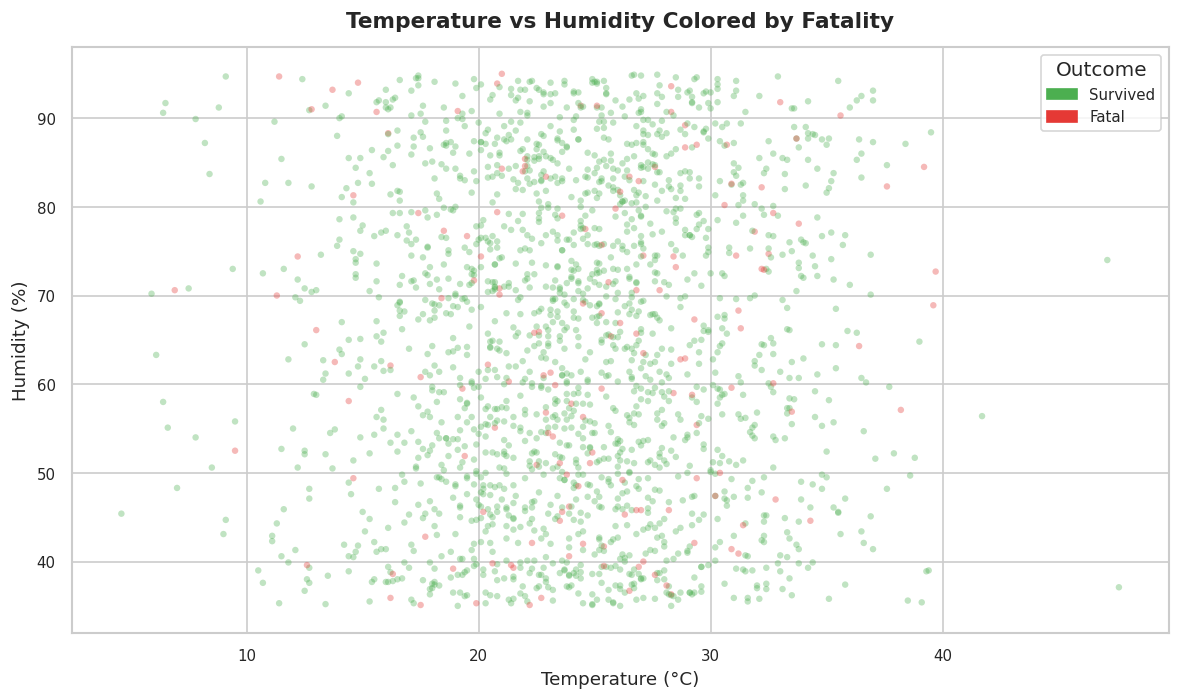

📌 Insight: Environmental conditions — particularly warm and humid climates —  support rodent breeding and virus persistence. Surveillance systems should  integrate real-time climate data for outbreak early warning.


In [31]:
# Plot 10: Temperature vs Humidity
if col_exists('temperature_celsius') and col_exists('humidity_percent'):
    fig, ax = plt.subplots(figsize=(10, 6))
    color_col = 'fatality' if col_exists('fatality') else None


    if color_col:
        colors = df_clean['fatality'].map({0: '#4CAF50', 1: '#E53935'})
        sc = ax.scatter(df_clean['temperature_celsius'], df_clean['humidity_percent'], c=colors, alpha=0.35, s=15, edgecolors='none')

        # Legend patches
        import matplotlib.patches as mpatches
        handles = [
            mpatches.Patch(color='#4CAF50', label='Survived'),
            mpatches.Patch(color='#E53935', label='Fatal')
        ]
        ax.legend(handles=handles, title='Outcome')
    else:
        ax.scatter(df_clean['temperature_celsius'], df_clean['humidity_percent'], alpha=0.3, color='steelblue', s=15)

    ax.set_title('Temperature vs Humidity Colored by Fatality', fontweight='bold', pad=12)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Humidity (%)')
    plt.tight_layout()
    plt.show()
    print('📌 Insight: Environmental conditions — particularly warm and humid climates —',
          ' support rodent breeding and virus persistence. Surveillance systems should',
          ' integrate real-time climate data for outbreak early warning.')

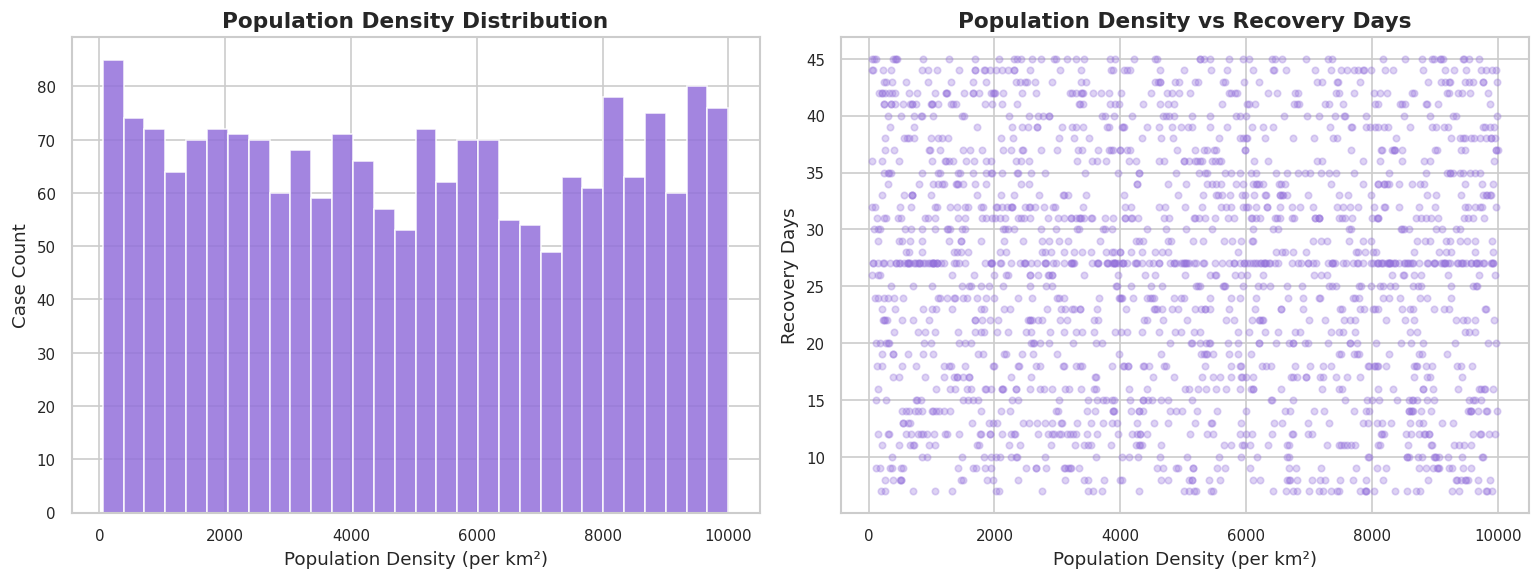

📌 Insight: Hantavirus is often paradoxically more common in rural/low-density  areas where rodent contact is higher. Dense urban areas may have limited exposure  but suffer worse outcomes due to air quality and healthcare access differences.


In [32]:
# Plot 11: Population Density vs Cases
if col_exists('population_density'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].hist(df_clean['population_density'].dropna(), bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
    axes[0].set_title('Population Density Distribution', fontweight='bold')
    axes[0].set_xlabel('Population Density (per km²)')
    axes[0].set_ylabel('Case Count')


    if col_exists('recovery_days'):
        axes[1].scatter(df_clean['population_density'], df_clean['recovery_days'], alpha=0.3, color='mediumpurple', s=15)
        axes[1].set_title('Population Density vs Recovery Days', fontweight='bold')
        axes[1].set_xlabel('Population Density (per km²)')
        axes[1].set_ylabel('Recovery Days')

    plt.tight_layout()
    plt.show()
    print('📌 Insight: Hantavirus is often paradoxically more common in rural/low-density',
          ' areas where rodent contact is higher. Dense urban areas may have limited exposure',
          ' but suffer worse outcomes due to air quality and healthcare access differences.')


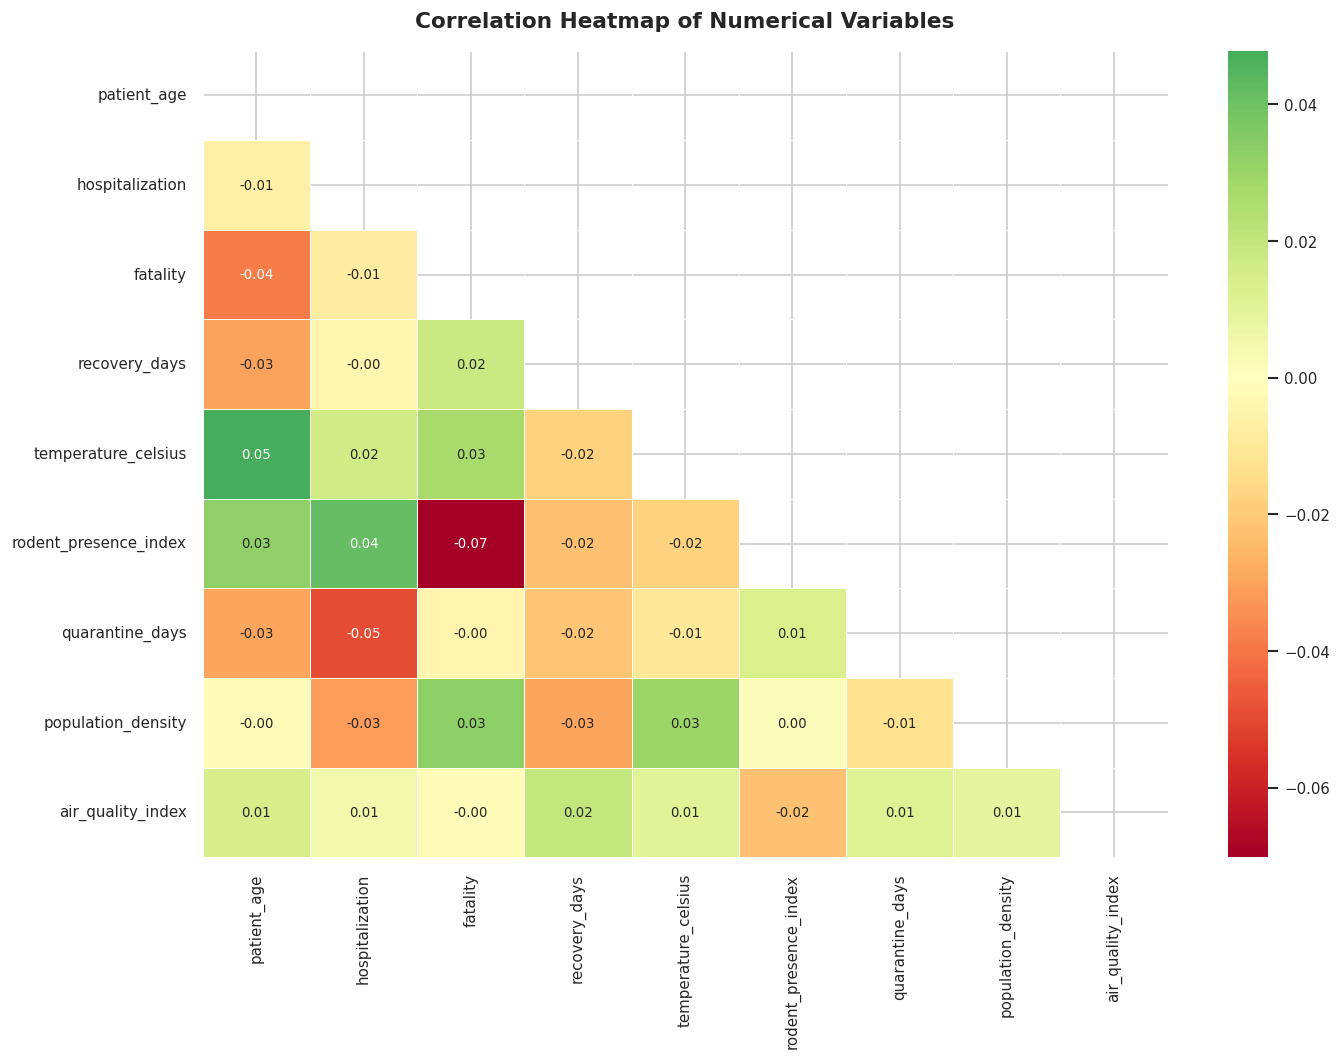

📌 Insight: The heatmap reveals feature relationships critical for model design.  Strong correlations between environmental variables and outcomes  validate the inclusion of climate data in outbreak risk models.


In [33]:
# Plot 12: Correlation Heatmap
num_df = df_clean.select_dtypes(include=['int64', 'float64'])
# Drop id-like columns
num_df = num_df[[c for c in num_df.columns if 'id' not in c.lower()]]

if num_df.shape[1] >= 3:
    corr_matrix = num_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title('Correlation Heatmap of Numerical Variables', fontweight='bold', pad=14)
    plt.tight_layout()
    plt.show()
    print('📌 Insight: The heatmap reveals feature relationships critical for model design.',
          ' Strong correlations between environmental variables and outcomes',
          ' validate the inclusion of climate data in outbreak risk models.')


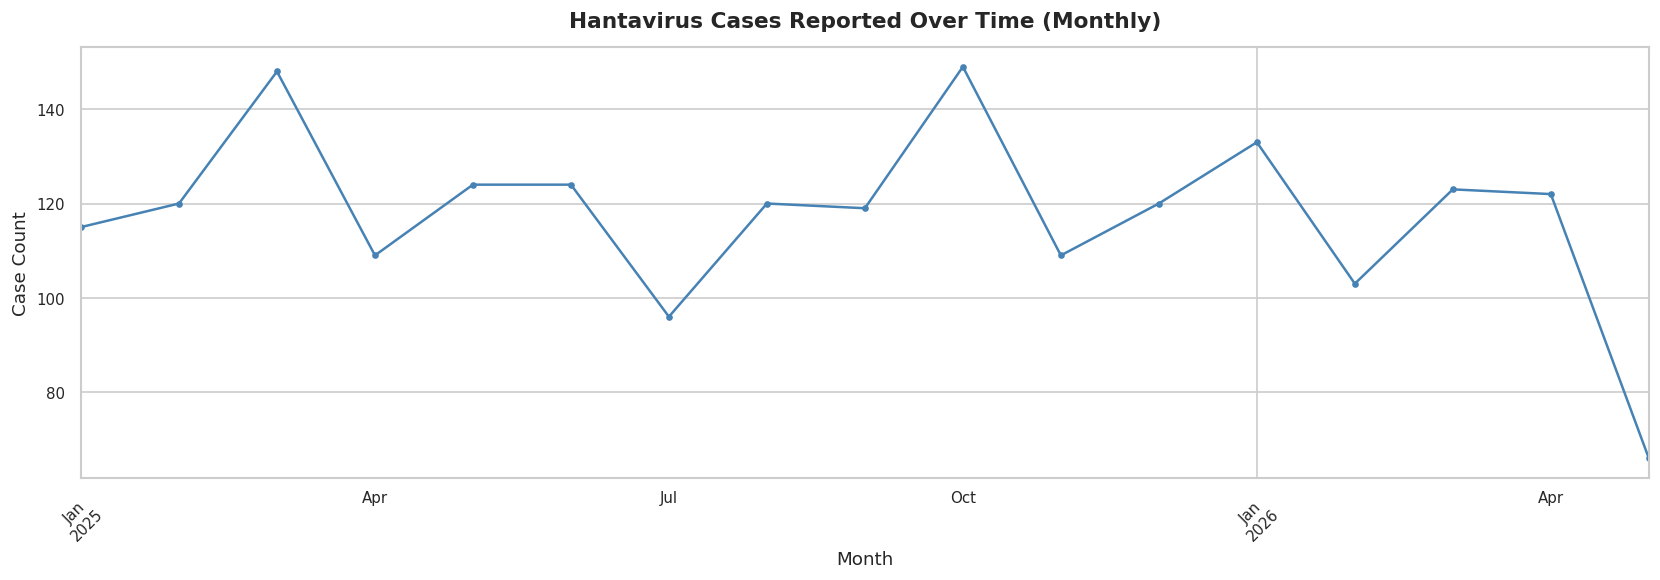

📌 Insight: Seasonal spikes in cases guide resource pre-positioning.  Peak periods typically align with rodent breeding seasons  or human agricultural activity in endemic zones.


In [34]:
# Plot 13: Time Series — Cases Over Time
date_cols = [c for c in df_clean.columns if 'date' in c.lower()]
if date_cols:
    dcol = date_cols[0]
    df_clean['year_month'] = df_clean[dcol].dt.to_period('M')
    monthly = df_clean.groupby('year_month').size()


    if len(monthly) > 2:
        fig, ax = plt.subplots(figsize=(14, 5))
        monthly.plot(kind='line', ax=ax, color='steelblue', marker='o', markersize=3, linewidth=1.5)
        ax.set_title('Hantavirus Cases Reported Over Time (Monthly)', fontweight='bold', pad=12)
        ax.set_xlabel('Month')
        ax.set_ylabel('Case Count')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
        print('📌 Insight: Seasonal spikes in cases guide resource pre-positioning.',
              ' Peak periods typically align with rodent breeding seasons',
              ' or human agricultural activity in endemic zones.')
    

In [35]:
# Feature Engineering
df_fe = df_clean.copy()

# 7.1 Age Groups
if col_exists('patient_age'):
    bins = [0, 12, 18, 35, 50, 65, 120]
    labels = ['Child(0-12)', 'Teen(13-18)', 'YoungAdult(19-35)', 'MiddleAge(36-50)', 'Senior(51-65)', 'Elderly(65+)']
    df_fe['age_group'] = pd.cut(df_fe['patient_age'], bins=bins, labels=labels, right=False)
    print('✅ age_group created')

# 7.2 Rodent Exposure Risk Level
if col_exists('rodent_presence_index'):
    df_fe['rodent_risk'] = pd.cut(df_fe['rodent_presence_index'],
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low', 'Moderate', 'High'],
        include_lowest=True)
    print('✅ rodent_risk created')

# 7.3 AQI Category
if col_exists('air_quality_index'):
    df_fe['aqi_category'] = pd.cut(
        df_fe['air_quality_index'],
        bins=[0, 50, 100, 150, 200, 500],
        labels=['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Hazardous'],
        include_lowest=True
    )
    print('✅ aqi_category created')


# 7.4 Population Density Category
if col_exists('population_density'):
    df_fe['density_category'] = pd.cut( df_fe['population_density'],
        bins=[0, 50, 200, 1000, 50000],
        labels=['Rural', 'Suburban', 'Urban', 'Megacity'],
        include_lowest=True)
    print('✅ density_category created')

# 7.5 Recovery Duration Category
if col_exists('recovery_days'):
    df_fe['recovery_category'] = pd.cut( df_fe['recovery_days'],
        bins=[0, 7, 14, 30, 365],
        labels=['Short(≤7d)', 'Moderate(8-14d)', 'Prolonged(15-30d)', 'Long(>30d)'],
        include_lowest=True)
    print('✅ recovery_category created')

# 7.6 Seasonal Feature from Report Date 
date_cols = [c for c in df_fe.columns if 'date' in c.lower() and str(df_fe[c].dtype).startswith('datetime')]
if date_cols:
    dcol = date_cols[0]
    df_fe['report_month'] = df_fe[dcol].dt.month
    df_fe['report_year'] = df_fe[dcol].dt.year
    df_fe['season'] = df_fe['report_month'].map({
         12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall',   10: 'Fall', 11: 'Fall'
    })
    print('✅ report_month, report_year, season created')
    
# 7.7 Environmental Risk Score
env_cols = [c for c in ['temperature_celsius', 'humidity_percent',
                         'rodent_presence_index', 'air_quality_index']
           if col_exists(c)]
if len(env_cols) >= 2:
    from sklearn.preprocessing import MinMaxScaler
    scaler_tmp =  MinMaxScaler()
    norm_env = scaler_tmp.fit_transform(df_fe[env_cols].fillna(0))
    df_fe['env_risk_score'] = norm_env.mean(axis=1)
    print('✅ env_risk_score created (composite environmental risk)')


print('\n📐 Feature engineering complete. New columns:')
new_feats = ['age_group', 'rodent_risk', 'aqi_category', 'density_category',
             'recovery_category', 'report_month', 'report_year', 'season', 'env_risk_score']
print([f for f in new_feats if f in df_fe.columns])  

✅ age_group created
✅ rodent_risk created
✅ aqi_category created
✅ density_category created
✅ recovery_category created
✅ report_month, report_year, season created
✅ env_risk_score created (composite environmental risk)

📐 Feature engineering complete. New columns:
['age_group', 'rodent_risk', 'aqi_category', 'density_category', 'recovery_category', 'report_month', 'report_year', 'season', 'env_risk_score']


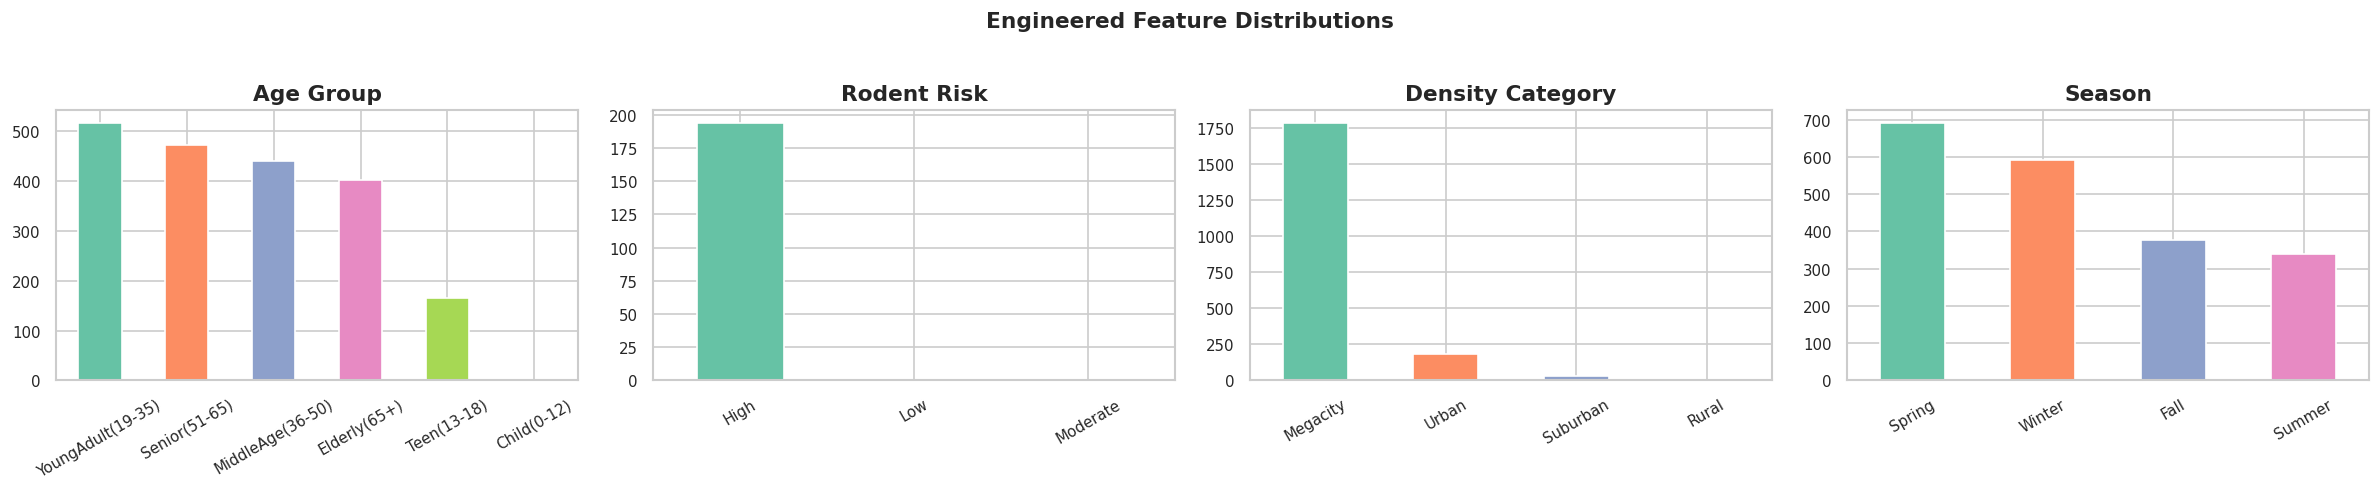

In [36]:
# Visualize engineered features
fig_cols = [c for c in ['age_group', 'rodent_risk', 'density_category', 'season']
            if c in df_fe.columns]
if fig_cols:
    n = len(fig_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, fig_cols):
        vc = df_fe[col].value_counts()
        vc.plot(kind='bar', ax=ax, color=PALETTE[:len(vc)], edgecolor='white')
        ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Engineered Feature Distributions', fontweight='bold', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

In [37]:
# Classification: Predicting Fatality
# Prepare classification dataset
TARGET_CLF = 'fatality'

if TARGET_CLF in df_fe.columns:
    # Select feature candidates
    candidate_feats = [
        'patient_age', 'temperature_celsius', 'humidity_percent',
        'rodent_presence_index', 'quarantine_days', 'population_density',
        'air_quality_index', 'recovery_days', 'hospitalization',
        'report_month', 'env_risk_score',
        'gender', 'virus_strain', 'transmission_type', 'exposure_source'
    ]
    avail_feats = [f for f in candidate_feats if f in df_fe.columns and f != TARGET_CLF]

    ml_df = df_fe[avail_feats + [TARGET_CLF]].copy().dropna()
    print(f'ML dataset shape: {ml_df.shape}')

    # Encode categoricals
    cat_feats = ml_df.select_dtypes(include='object').columns.tolist()
    le = LabelEncoder()
    for col in cat_feats:
        ml_df[col] = le.fit_transform(ml_df[col].astype(str))

    X = ml_df[avail_feats]
    y = ml_df[TARGET_CLF]

    # Class balance check
    print(f'Target distribution:\n{y.value_counts(normalize=True).round(3)}')

    X_train, X_test, y_train, y_test = train_test_split(
         X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    print(f'\nTrain size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
    print('✅ Data split and scaled.')
else:
    print('⚠️  Target column "fatality" not found. Skipping classification.')

ML dataset shape: (2000, 16)
Target distribution:
fatality
0    0.922
1    0.078
Name: proportion, dtype: float64

Train size: 1,600 | Test size: 400
✅ Data split and scaled.


In [38]:
# Train classifiers
if TARGET_CLF in df_fe.columns:
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
        'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=SEED),
        'Random Forest':       RandomForestClassifier(n_estimators=150, max_depth=10,
                                                       random_state=SEED, n_jobs=-1)
      }
    results_clf = []
    fitted_models = {}

    for name, clf in classifiers.items():
        if 'Logistic' in name:
            clf.fit(X_train_sc, y_train)
            preds = clf.predict(X_test_sc)
        else:
            clf.fit(X_train, y_train)
            preds = clf.predict(X_test)

        fitted_models[name] = (clf, preds)
        results_clf.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1 Score': f1_score(y_test, preds, zero_division=0)
        })
    results_clf_df = pd.DataFrame(results_clf).sort_values('F1 Score', ascending=False)
    display(results_clf_df.style.format('{:.4f}', subset=['Accuracy','Precision','Recall','F1 Score'])
                                 .background_gradient(cmap='Greens', subset=['F1 Score']))

    


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.9650,0.7931,0.7419,0.7667
2,Random Forest,0.9300,0.6667,0.1935,0.3000
0,Logistic Regression,0.9225,0.0000,0.0000,0.0000


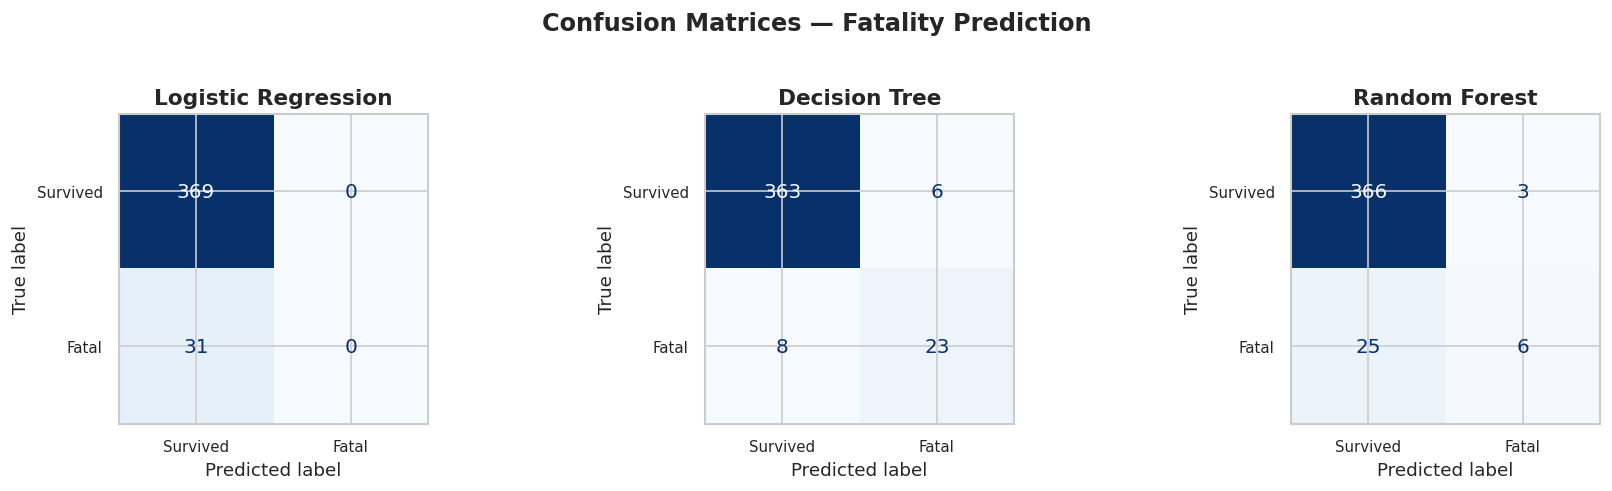

In [39]:
# Confusion Matrices 
if TARGET_CLF in df_fe.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, (clf, preds)) in zip(axes, fitted_models.items()):
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Survived', 'Fatal'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(name, fontweight='bold')
    plt.suptitle('Confusion Matrices — Fatality Prediction', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
        

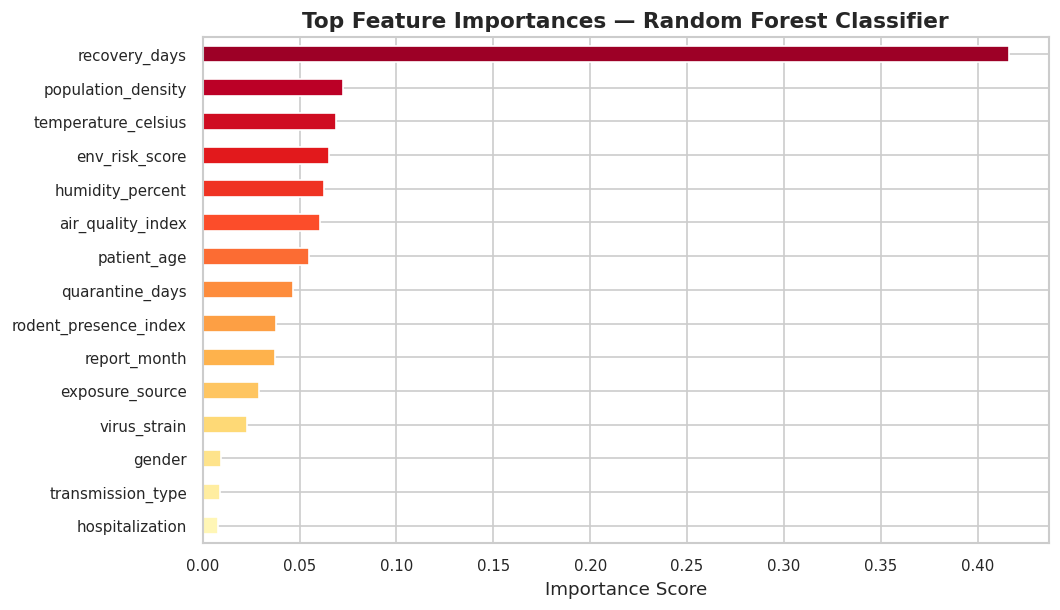

Insight: The most predictive features guide both clinical decision-making and  public health screening tools. Environmental variables appearing high up validate  climate-informed surveillance.


In [40]:
# Feature Importance (Random Forest)
if TARGET_CLF in df_fe.columns and 'Random Forest' in fitted_models:
    rf_clf = fitted_models['Random Forest'][0]
    fi = pd.Series(rf_clf.feature_importances_, index=avail_feats).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4, len(fi) * 0.35)))
    fi.tail(15).plot(kind='barh', ax=ax,
                     color=sns.color_palette('YlOrRd', 15), edgecolor='white')
    ax.set_title('Top Feature Importances — Random Forest Classifier', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    print('Insight: The most predictive features guide both clinical decision-making and',
          ' public health screening tools. Environmental variables appearing high up validate',
          ' climate-informed surveillance.')

In [41]:
TARGET_REG = 'recovery_days'

if TARGET_REG in df_fe.columns:
    reg_candidates = [
        'patient_age', 'temperature_celsius', 'humidity_percent',
        'rodent_presence_index', 'quarantine_days', 'population_density',
        'air_quality_index', 'hospitalization', 'fatality',
        'report_month', 'env_risk_score',
        'gender', 'virus_strain', 'transmission_type', 'exposure_source'
    ]
    reg_feats = [f for f in reg_candidates if f in df_fe.columns and f != TARGET_REG]

    reg_df = df_fe[reg_feats + [TARGET_REG]].copy().dropna()

    # Encode categoricals
    cat_reg = reg_df.select_dtypes(include='object').columns.tolist()
    le2 = LabelEncoder()
    for col in cat_reg:
        reg_df[col] = le2.fit_transform(reg_df[col].astype(str))

    X_r = reg_df[reg_feats]
    y_r = reg_df[TARGET_REG]

    X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
        X_r, y_r, test_size=0.2, random_state=SEED
    )
    scaler_r = StandardScaler()
    X_r_train_sc = scaler_r.fit_transform(X_r_train)
    X_r_test_sc = scaler_r.transform(X_r_test)

    regressors = {
        'Linear Regression':      (LinearRegression(), True),
        'Random Forest Regressor': (RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1), False)
    }

    results_reg = []
    for name, (model, use_scaled) in regressors.items():
        Xtr = X_r_train_sc if use_scaled else X_r_train
        Xte = X_r_test_sc  if use_scaled else X_r_test
        model.fit(Xtr, y_r_train)
        preds_r = model.predict(Xte)
        results_reg.append({
            'Model': name,
            'MAE':   mean_absolute_error(y_r_test, preds_r),
            'RMSE':  np.sqrt(mean_squared_error(y_r_test, preds_r)),
            'R²':    r2_score(y_r_test, preds_r)
        })

    results_reg_df = pd.DataFrame(results_reg)
    display(results_reg_df.style.format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'R²': '{:.4f}'})
                                  .background_gradient(cmap='Greens', subset=['R²']))
else:
    print('⚠️  Target column "recovery_days" not found. Skipping regression.')

,Model,MAE,RMSE,R²
0,Linear Regression,9.03,10.77,-0.0046
1,Random Forest Regressor,9.08,10.86,-0.0203


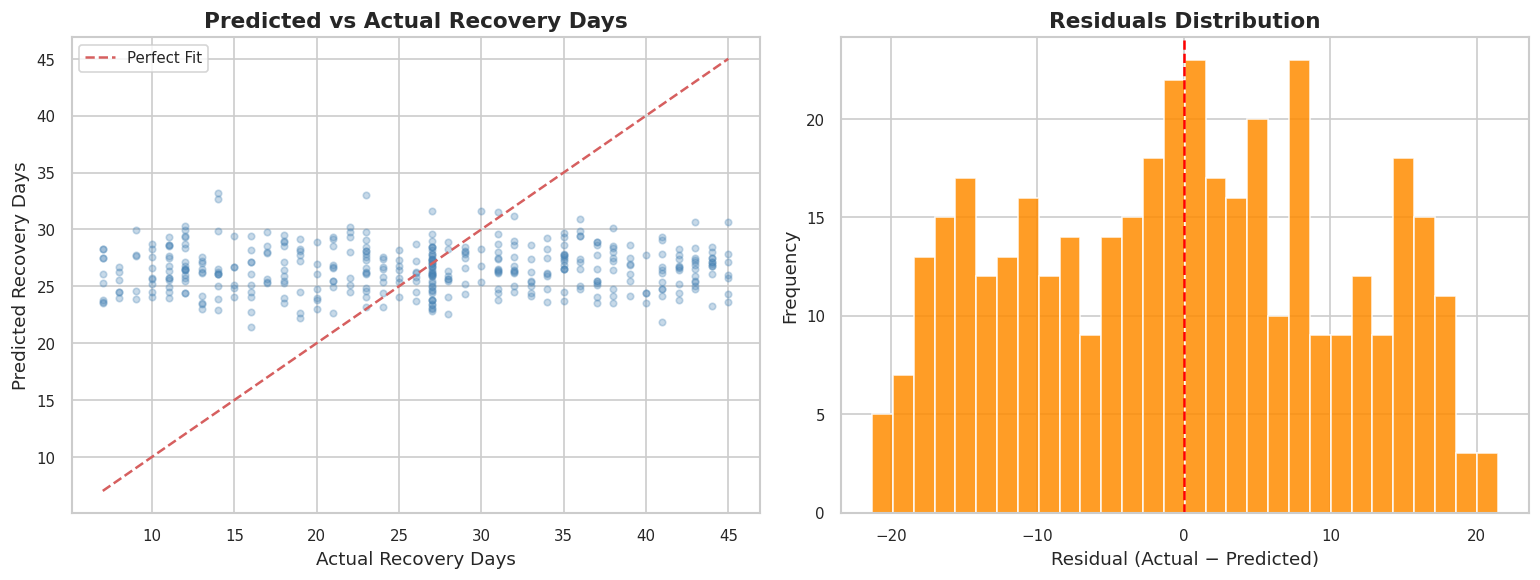

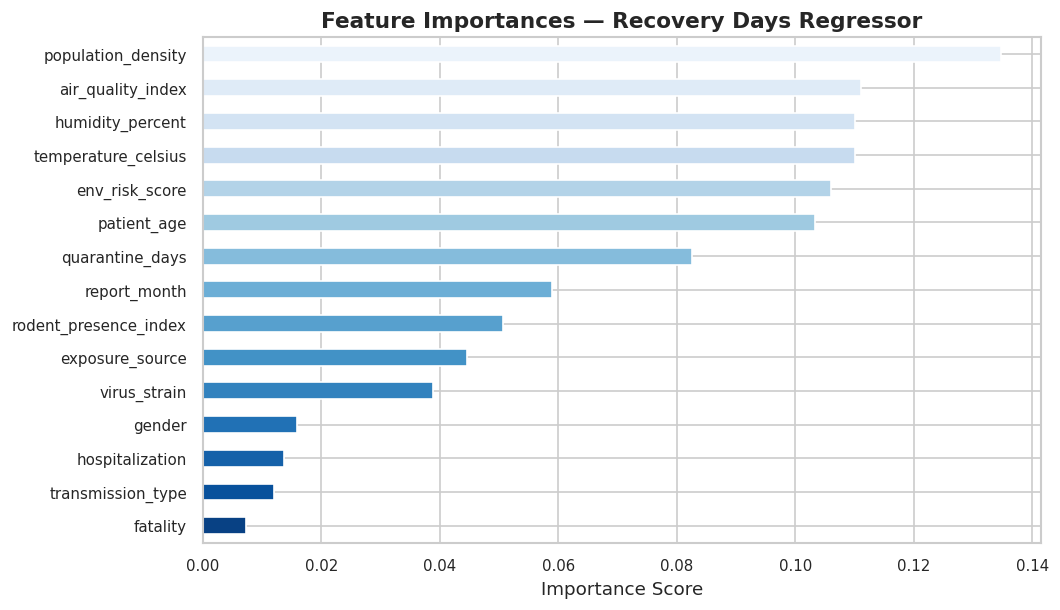

In [42]:
# Predicted vs Actual — Random Forest Regressor
if TARGET_REG in df_fe.columns:
    rf_reg = regressors['Random Forest Regressor'][0]
    rf_preds_r = rf_reg.predict(X_r_test)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Predicted vs actual scatter
    axes[0].scatter(y_r_test, rf_preds_r, alpha=0.3, color='steelblue', s=15)
    lo, hi = min(y_r_test.min(), rf_preds_r.min()), max(y_r_test.max(), rf_preds_r.max())
    axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect Fit')
    axes[0].set_title('Predicted vs Actual Recovery Days', fontweight='bold')
    axes[0].set_xlabel('Actual Recovery Days')
    axes[0].set_ylabel('Predicted Recovery Days')
    axes[0].legend()

    # Residuals
    residuals = y_r_test - rf_preds_r
    axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title('Residuals Distribution', fontweight='bold')
    axes[1].set_xlabel('Residual (Actual − Predicted)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Feature importance
    fi_r = pd.Series(rf_reg.feature_importances_, index=reg_feats).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, max(4, len(fi_r) * 0.35)))
    fi_r.tail(15).plot(kind='barh', ax=ax,
                        color=sns.color_palette('Blues_r', 15), edgecolor='white')
    ax.set_title('Feature Importances — Recovery Days Regressor', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [43]:
print('=' * 65)
print('PUBLIC HEALTH INSIGHTS SUMMARY')
print('=' * 65)

if col_exists('country'):
    top5 = df_clean['country'].value_counts().head(5)
    print(f'\n Top 5 countries by case count:')
    for c, n in top5.items():
        print(f'   {c:<25} {n:>6,} cases')

if col_exists('virus_strain'):
    top_strain = df_clean['virus_strain'].mode()[0]
    print(f'\n Most prevalent virus strain: {top_strain}')

if col_exists('transmission_type'):
    top_tx = df_clean['transmission_type'].mode()[0]
    print(f'\n Most common transmission type: {top_tx}')

if col_exists('fatality'):
    cfr = df_clean['fatality'].mean() * 100
    print(f'\n Case Fatality Rate (CFR): {cfr:.2f}%')

if col_exists('hospitalization'):
    hosp_rate = df_clean['hospitalization'].mean() * 100
    print(f' Hospitalization Rate: {hosp_rate:.2f}%')

if col_exists('recovery_days'):
    med_rec = df_clean['recovery_days'].median()
    print(f' Median Recovery Days: {med_rec:.1f}')

if col_exists('patient_age'):
    print(f'\n Age Stats:')
    print(f'   Mean age:   {df_clean["patient_age"].mean():.1f} years')
    print(f'   Median age: {df_clean["patient_age"].median():.1f} years')
    if col_exists('fatality'):
        avg_age_fatal = df_clean[df_clean['fatality']==1]['patient_age'].mean()
        avg_age_surv  = df_clean[df_clean['fatality']==0]['patient_age'].mean()
        print(f' Mean age (fatal): {avg_age_fatal:.1f} | (survived): {avg_age_surv:.1f}')

if col_exists('rodent_presence_index') and col_exists('fatality'):
    high_risk_cfr = df_clean[df_clean['rodent_presence_index'] > 0.7]['fatality'].mean() * 100
    low_risk_cfr  = df_clean[df_clean['rodent_presence_index'] <= 0.3]['fatality'].mean() * 100
    print(f'\n CFR in high rodent-risk zones:  {high_risk_cfr:.2f}%')
    print(f'   CFR in low rodent-risk zones:   {low_risk_cfr:.2f}%')

print('\n' + '=' * 65)

PUBLIC HEALTH INSIGHTS SUMMARY

 Top 5 countries by case count:
   Bolivia                      215 cases
   Argentina                    211 cases
   Canada                       208 cases
   USA                          208 cases
   Brazil                       207 cases

 Most prevalent virus strain: Sin Nombre

 Most common transmission type: Human-to-Human

 Case Fatality Rate (CFR): 7.75%
 Hospitalization Rate: 50.35%
 Median Recovery Days: 27.0

 Age Stats:
   Mean age:   45.2 years
   Median age: 46.0 years
 Mean age (fatal): 42.7 | (survived): 45.4

 CFR in high rodent-risk zones:  7.75%
   CFR in low rodent-risk zones:   nan%



My name is Edwin Muchira  

In [44]:
df.isna().sum()

case_id                  0
country                  0
region                   0
report_date              0
virus_strain             0
transmission_type        0
exposure_source          0
patient_age              0
gender                   0
symptoms                 0
hospitalization          0
fatality                 0
recovery_days            0
temperature_celsius      0
humidity_percent         0
rodent_presence_index    0
quarantine_days          0
population_density       0
air_quality_index        0
dtype: int64